In [4]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
import matplotlib.pyplot as plt

def get_stock_data(tickers, start_date, end_date):
    """
    Fetch historical adjusted close prices for multiple tickers.
    """
    try:
        data = yf.download(
            tickers,
            start=start_date,
            end=end_date,
            auto_adjust=True, 
            progress=False
        )

        # Always return Close prices as a clean DataFrame
        if isinstance(tickers, list):
            return data['Close']
        else:
            return data[['Close']]

    except Exception as e:
        print(f"Error fetching data: {e}")
        return None


def get_stock_details(price_data):
    """
    Calculate mean returns and covariance matrix.
    """
    returns = price_data.pct_change().dropna()

    mean_returns = returns.mean() # average daily return per stock
    cov_matrix = returns.cov() # covariance of returns between stocks

    return mean_returns, cov_matrix


# --- usage ---
stock_list = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']

end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=365)

prices = get_stock_data(stock_list, start_date, end_date)

if prices is not None:
    mean_returns, cov_matrix = get_stock_details(prices)

    print("Mean Returns:\n", mean_returns)
    print("\nCovariance Matrix:\n", cov_matrix)

Mean Returns:
 Ticker
AAPL     0.001476
AMZN     0.001816
GOOGL    0.003549
META     0.001672
MSFT     0.000805
dtype: float64

Covariance Matrix:
 Ticker      AAPL      AMZN     GOOGL      META      MSFT
Ticker                                                  
AAPL    0.000220  0.000107  0.000091  0.000087  0.000038
AMZN    0.000107  0.000389  0.000145  0.000226  0.000113
GOOGL   0.000091  0.000145  0.000325  0.000133  0.000055
META    0.000087  0.000226  0.000133  0.000502  0.000127
MSFT    0.000038  0.000113  0.000055  0.000127  0.000237


In [5]:
weights = np.random.random(len(stock_list))
weights = weights / np.sum(weights) # normalize the weights to sum to 1

# monte carlo simulation
mc_sims = 100
T = 100 # timeframe in days

meanMatrix = np.full(shape=(T, len(stock_list)), fill_value=mean_returns)
meanMatrix = meanMatrix.T

protfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)

initial_investment = 1000000

for m in range(0, mc_sims):
    z = np.random.normal(size=(T, len(stock_list))) # generate random normal variables for the simulation
    L = np.linalg.cholesky(cov_matrix) # Cholesky decomposition to get the lower triangular matrix
    daily_returns = meanMatrix + np.inner(L, z) # calculate daily returns using the mean and the Cholesky decomposition
    protfolio_sims[:, m] = np.cumprod(np.inner(weights, daily_returns.T) + 1) * initial_investment # calculate the cumulative product of returns to get the portfolio value over time

    


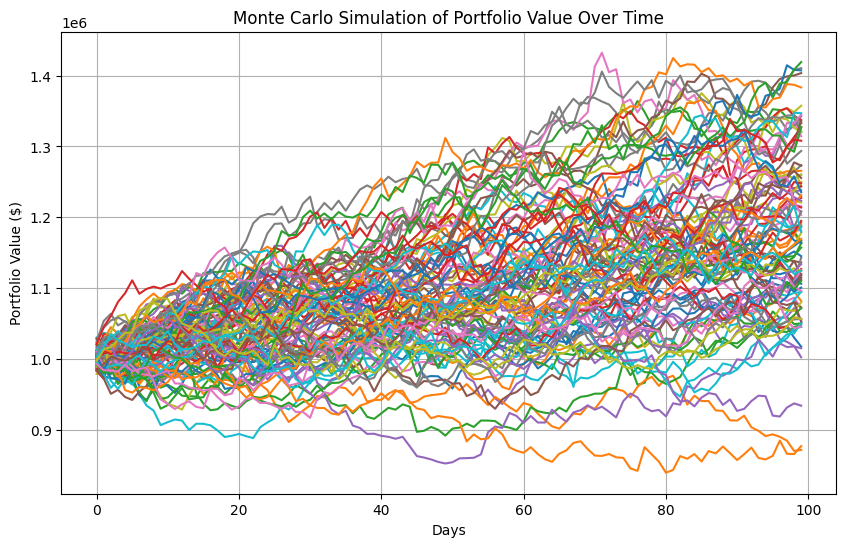

95% Confidence Interval for Final Portfolio Value: $966,319.13 - $1,405,678.28
Mean Final Portfolio Value: $1,182,463.53
Probability of Portfolio Value Being Above Initial Investment: 97.00%
Probability of Portfolio Value Being Below Initial Investment: 3.00%
Risk (Standard Deviation of Final Portfolio Value): $115,979.06
Risk-Adjusted Return (Sharpe Ratio): 1.57
Expected Shortfall (CVaR) at 95% Confidence Level: $939,802.58


In [6]:
# plot the results
plt.figure(figsize=(10, 6))
plt.plot(protfolio_sims)
plt.title('Monte Carlo Simulation of Portfolio Value Over Time')
plt.xlabel('Days')
plt.ylabel('Portfolio Value ($)')
plt.grid()
plt.show()

# calculate the 95% confidence interval for the final portfolio value
final_values = protfolio_sims[-1, :]
lower_bound = np.percentile(final_values, 2.5)
upper_bound = np.percentile(final_values, 97.5)
print(f"95% Confidence Interval for Final Portfolio Value: ${lower_bound:,.2f} - ${upper_bound:,.2f}")

# calculate the mean final portfolio value
mean_final_value = np.mean(final_values)
print(f"Mean Final Portfolio Value: ${mean_final_value:,.2f}")

# calculate the probability of the portfolio value being above the initial investment
probability_above_initial = np.mean(final_values > initial_investment)
print(f"Probability of Portfolio Value Being Above Initial Investment: {probability_above_initial:.2%}")

# calculate the probability of the portfolio value being below the initial investment
probability_below_initial = np.mean(final_values < initial_investment)
print(f"Probability of Portfolio Value Being Below Initial Investment: {probability_below_initial:.2%}")

# caclulate the risk
risk = np.std(final_values)
print(f"Risk (Standard Deviation of Final Portfolio Value): ${risk:,.2f}")

# caculate the risk-adjusted return (Sharpe Ratio)
expected_return = mean_final_value - initial_investment
risk_adjusted_return = expected_return / risk
print(f"Risk-Adjusted Return (Sharpe Ratio): {risk_adjusted_return:.2f}")

# calculate the expected shortfall (CVaR) at the 95% confidence level
cvar_threshold = np.percentile(final_values, 5)
expected_shortfall = np.mean(final_values[final_values < cvar_threshold])
print(f"Expected Shortfall (CVaR) at 95% Confidence Level: ${expected_shortfall:,.2f}")
